In [35]:
# !pip install tqdm

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import importlib

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import train_test_split

from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score
import statsmodels.api as sm

import tabular_pipeline
importlib.reload(tabular_pipeline)
from tabular_pipeline import tabular_pipeline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
sns.set_style("whitegrid")

print("Libraries imported successfully.")

Libraries installed successfully..
Libraries imported successfully.


In [37]:
DATA_PATH = "breast_cancer.csv"

# Target column in the WDBC dataset
TARGET_COLUMN = "diagnosis"

print("Dataset path:", DATA_PATH)
print("Target column:", TARGET_COLUMN)


df = pd.read_csv(DATA_PATH)

print("Dataset Shape:", df.shape)

print("\nFirst 5 rows:")
display(df.head())

print("\nLast 5 rows:")
display(df.tail())

print("\nColumn Names:")
print(df.columns.tolist())


Dataset path: breast_cancer.csv
Target column: diagnosis
Dataset Shape: (569, 33)

First 5 rows:


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN



Last 5 rows:


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,1.1760,1.256,7.673,158.70,0.010300,0.02891,0.05198,0.02454,0.01114,0.004239,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,NaN
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,0.7655,2.463,5.203,99.04,0.005769,0.02423,0.03950,0.01678,0.01898,0.002498,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,NaN
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,0.4564,1.075,3.425,48.55,0.005903,0.03731,0.04730,0.01557,0.01318,0.003892,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,NaN
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,0.7260,1.595,5.772,86.22,0.006522,0.06158,0.07117,0.01664,0.02324,0.006185,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,NaN
568,92751,B,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,0.1587,0.05884,0.3857,1.428,2.548,19.15,0.007189,0.00466,0.00000,0.00000,0.02676,0.002783,9.456,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.0000,0.2871,0.07039,NaN



Column Names:
['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32']


In [38]:
if "id" in df.columns:
    df = df.drop(columns=["id"])
    print("'id' column removed because it is only an identifier.")

print("New dataset shape:", df.shape)



print("Original class distribution:")
print(df[TARGET_COLUMN].value_counts())

df[TARGET_COLUMN] = df[TARGET_COLUMN].map({
    "B": 0,
    "M": 1
})

print("\nEncoded class distribution:")
print(df[TARGET_COLUMN].value_counts())

print("\nClass meaning:")
print("0 = Benign")
print("1 = Malignant")

'id' column removed because it is only an identifier.
New dataset shape: (569, 32)
Original class distribution:
diagnosis
B    357
M    212
Name: count, dtype: int64

Encoded class distribution:
diagnosis
0    357
1    212
Name: count, dtype: int64

Class meaning:
0 = Benign
1 = Malignant


Class Distribution
------------------
Benign    : 357
Malignant : 212


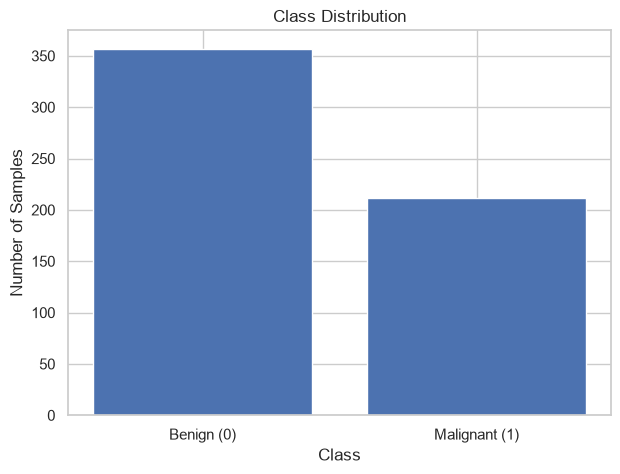

In [39]:
# Class Distribution (specifically asked)

class_counts = df[TARGET_COLUMN].value_counts().sort_index()

class_labels = ["Benign (0)", "Malignant (1)"]

print("Class Distribution")
print("------------------")
print("Benign    :", class_counts.get(0, 0))
print("Malignant :", class_counts.get(1, 0))

plt.figure(figsize=(7, 5))

plt.bar(
    class_labels,
    [class_counts.get(0, 0), class_counts.get(1, 0)]
)

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Samples")

plt.show()

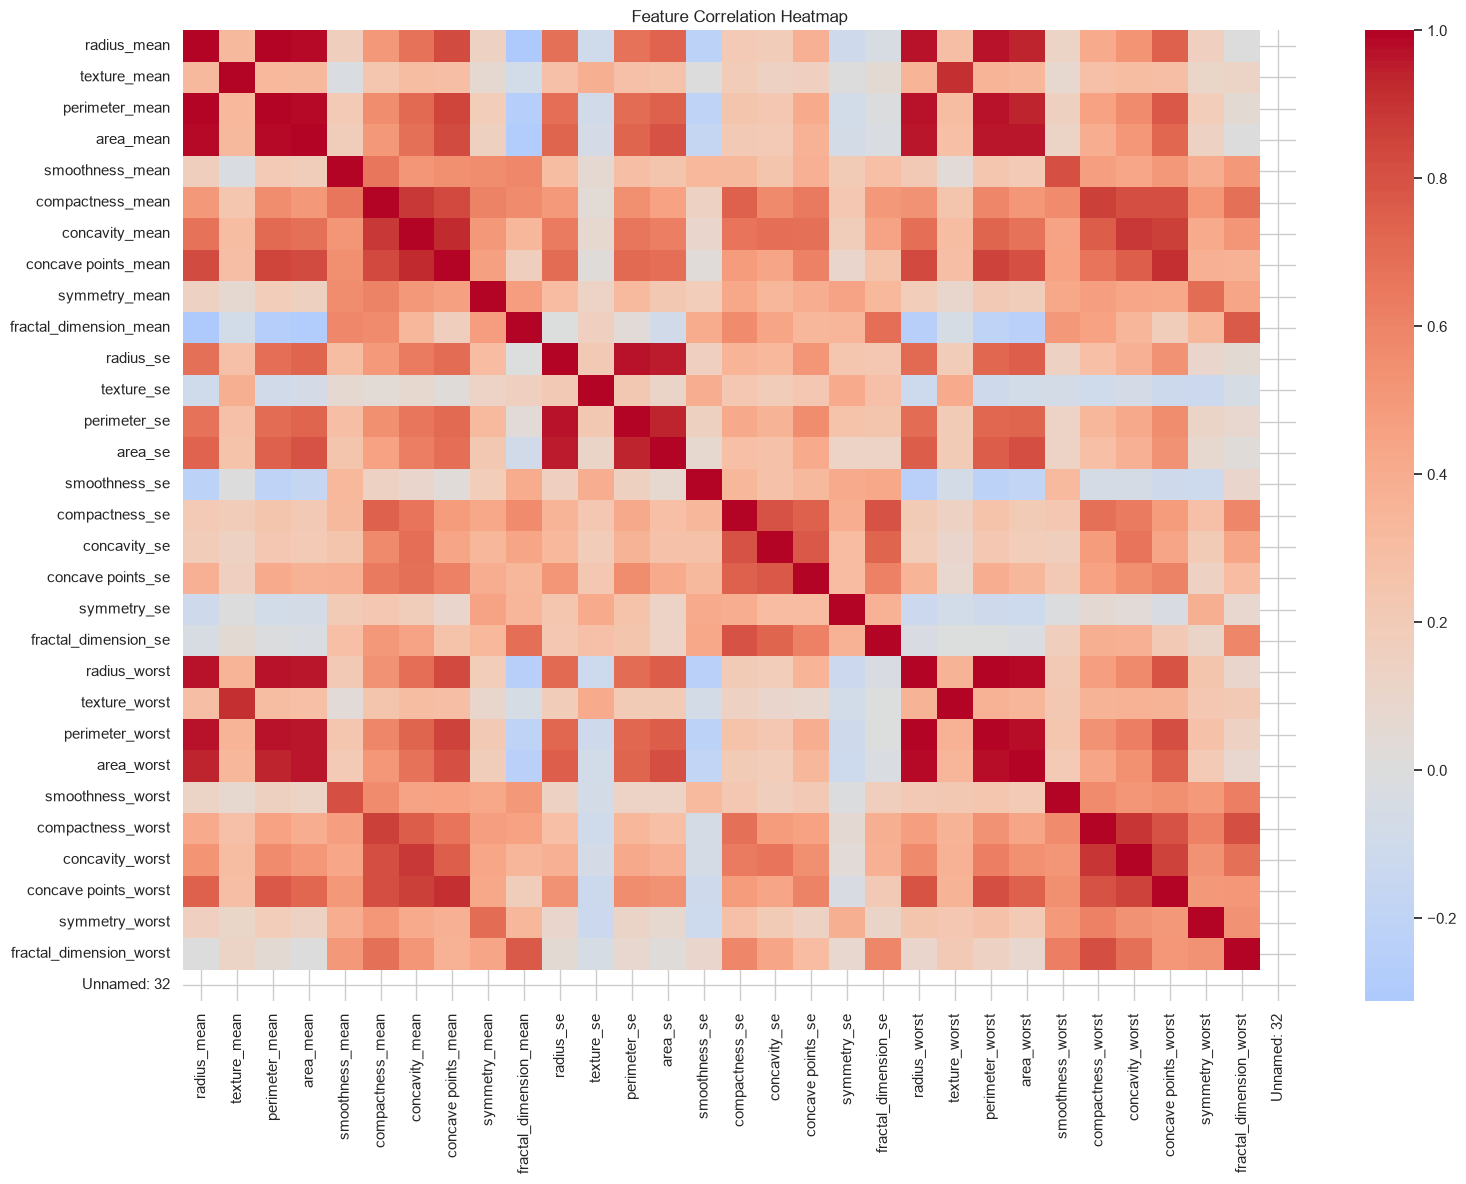

In [40]:
# Feature Correlation Analysis
X_corr = df.drop(columns=[TARGET_COLUMN])

correlation_matrix = X_corr.corr()

plt.figure(figsize=(16, 12))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlation Heatmap")
plt.tight_layout()

plt.show()


[PIPELINE] Starting Tabular Data Processing Pipeline...


[ROUTE] Successfully sent to Tabular EDA.


-> Processing data file: 'breast_cancer.csv'



Removed entirely empty columns: ['Unnamed: 32']
The shape of the dataset: (569, 32)
         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  smoothness_mean  compactness_mean  \
0    842302         M        17.99         10.38          122.80     1001.0          0.11840           0.27760   
1    842517         M        20.57         17.77          132.90     1326.0          0.08474           0.07864   
2  84300903         M        19.69         21.25          130.00     1203.0          0.10960           0.15990   
3  84348301         M        11.42         20.38           77.58      386.1          0.14250           0.28390   
4  84358402         M        20.29         14.34          135.10     1297.0          0.10030           0.13280   

   concavity_mean  concave points_mean  symmetry_mean  fractal_dimension_mean  r

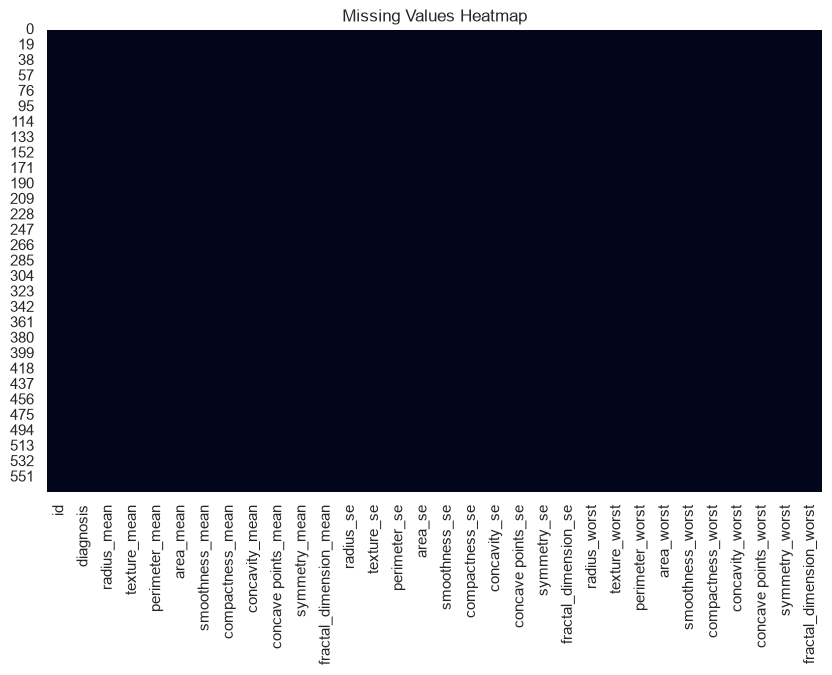



Central Tendency: 

Column: 'id'
  -> Mean:   30371831.43
  -> Median: 906024.00
  -> Mode:   8670
  -> skew:   6.473751801630769
  -> Kurtosis:   42.193194161021005
count    5.690000e+02
mean     3.037183e+07
std      1.250206e+08
min      8.670000e+03
25%      8.692180e+05
50%      9.060240e+05
75%      8.813129e+06
max      9.113205e+08
Name: id, dtype: float64

Column: 'radius_mean'
  -> Mean:   14.13
  -> Median: 13.37
  -> Mode:   12.34
  -> skew:   0.9423795716730992
  -> Kurtosis:   0.8455216229065377
count    569.000000
mean      14.127292
std        3.524049
min        6.981000
25%       11.700000
50%       13.370000
75%       15.780000
max       28.110000
Name: radius_mean, dtype: float64

Column: 'texture_mean'
  -> Mean:   19.29
  -> Median: 18.84
  -> Mode:   14.93
  -> skew:   0.6504495420828159
  -> Kurtosis:   0.7583189723727752
count    569.000000
mean      19.289649
std        4.301036
min        9.710000
25%       16.170000
50%       18.840000
75%       21.800000


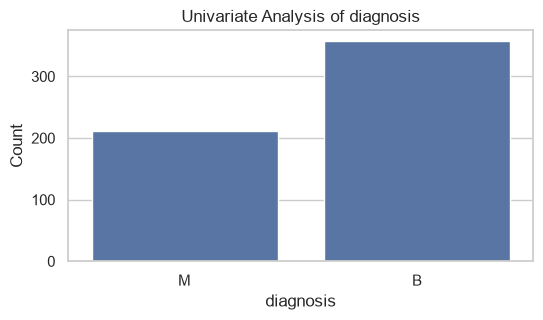

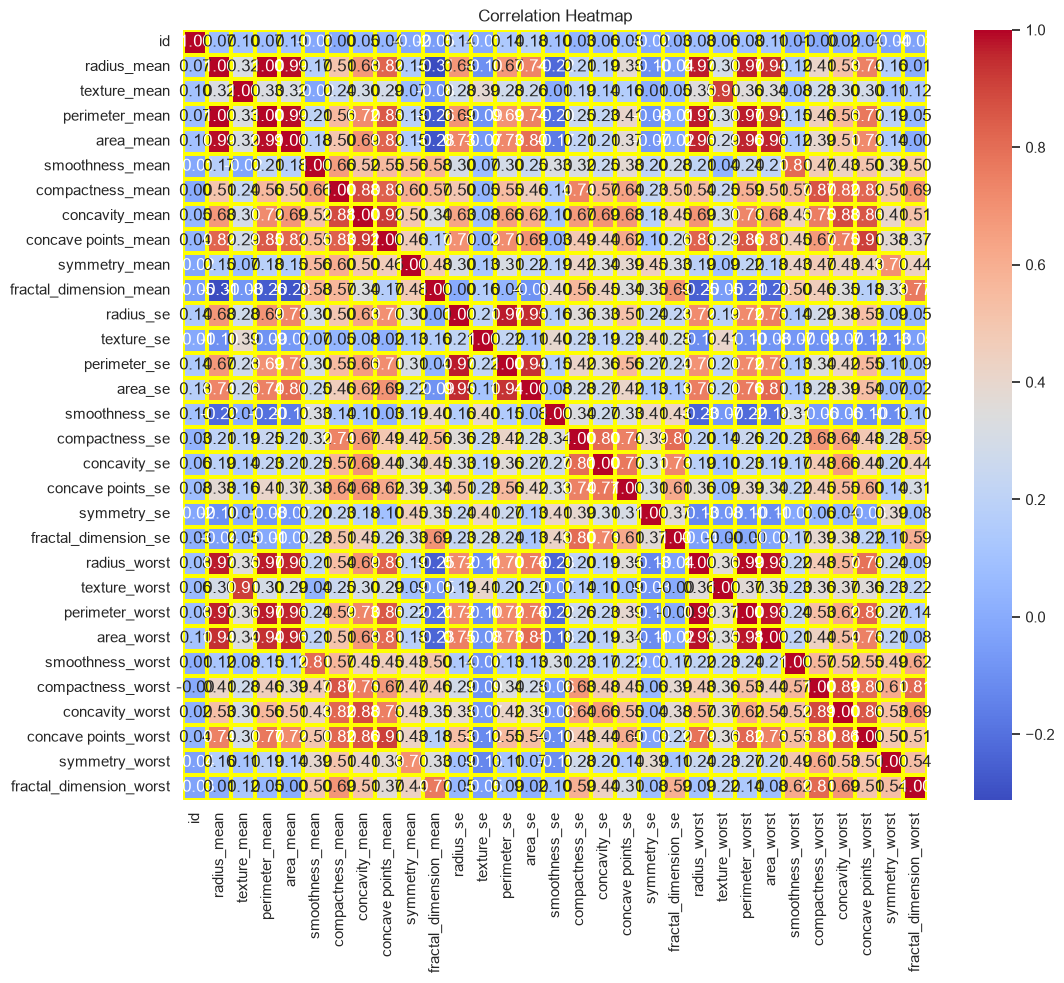



                   features          VIF
1               radius_mean  3806.464754
3            perimeter_mean  3786.400488
21             radius_worst   799.418629
23          perimeter_worst   405.023630
4                 area_mean   347.968386
24               area_worst   337.319359
11                radius_se    75.653561
7            concavity_mean    70.785037
13             perimeter_se    70.363596
8       concave points_mean    60.060406
6          compactness_mean    50.527114
14                  area_se    41.688437
26        compactness_worst    37.010829
28     concave points_worst    36.791231
27          concavity_worst    31.971022
30  fractal_dimension_worst    18.863976
22            texture_worst    18.570023
10   fractal_dimension_mean    15.759755
17             concavity_se    15.699567
16           compactness_se    15.378147
2              texture_mean    11.901803
18        concave points_se    11.592109
25         smoothness_worst    10.925873
20     fractal

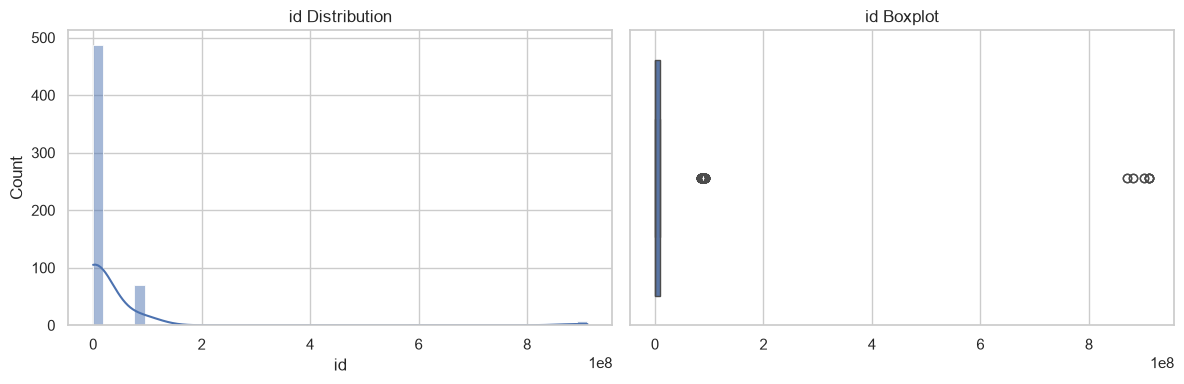

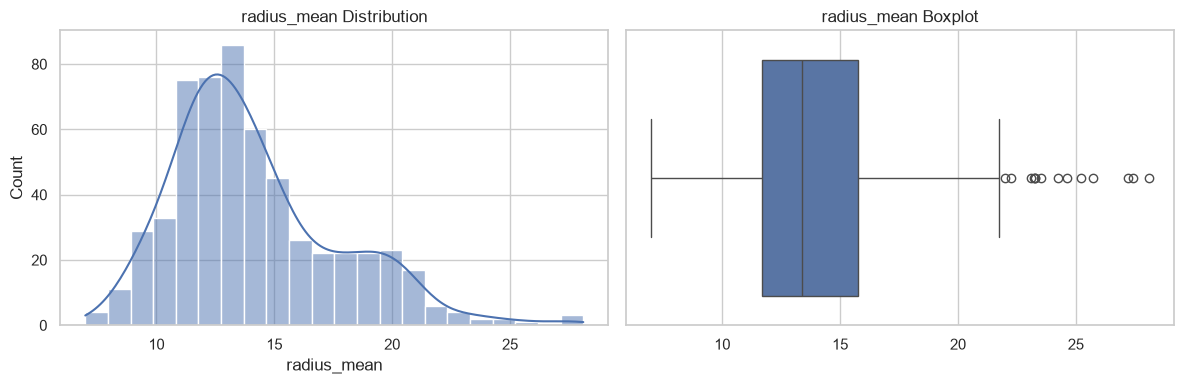

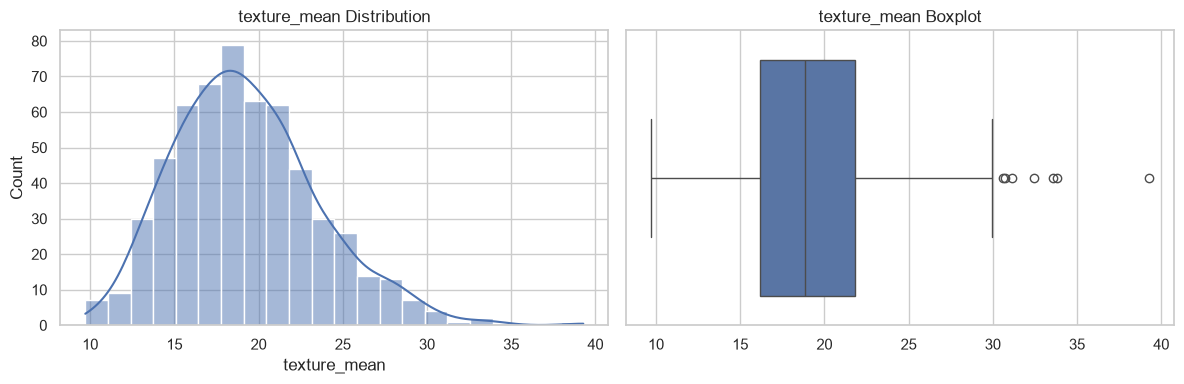

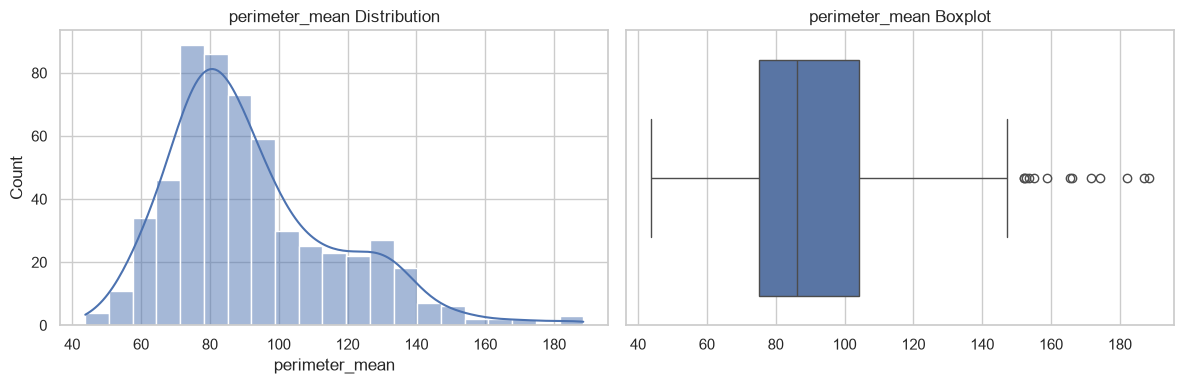

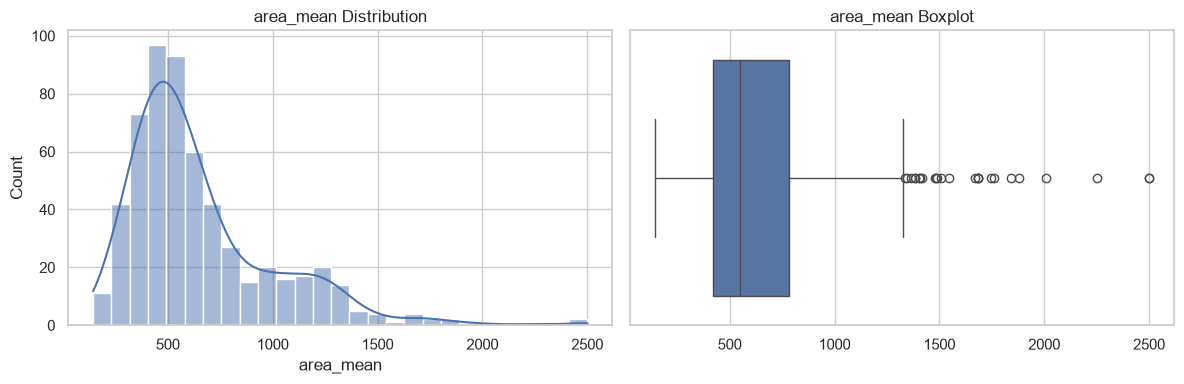

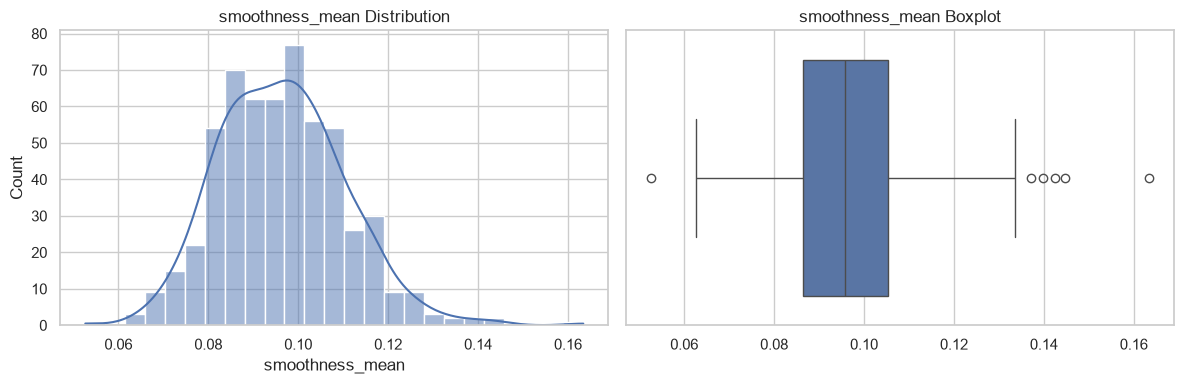

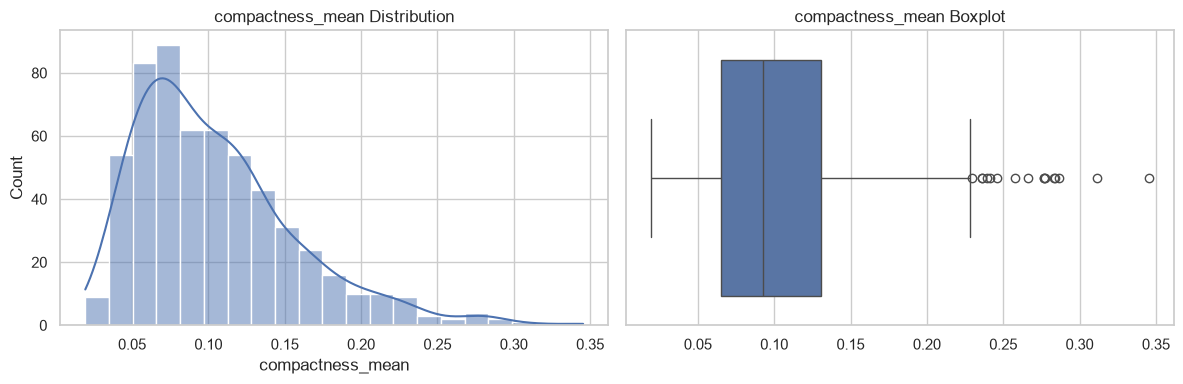

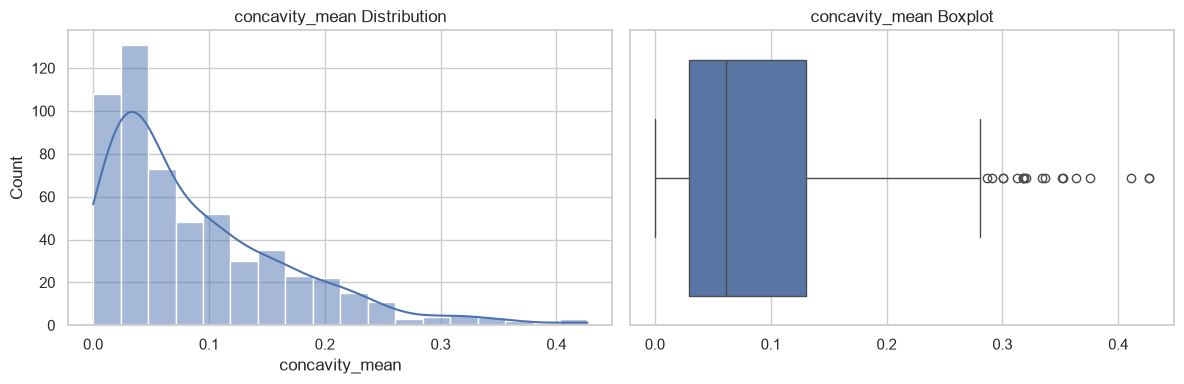

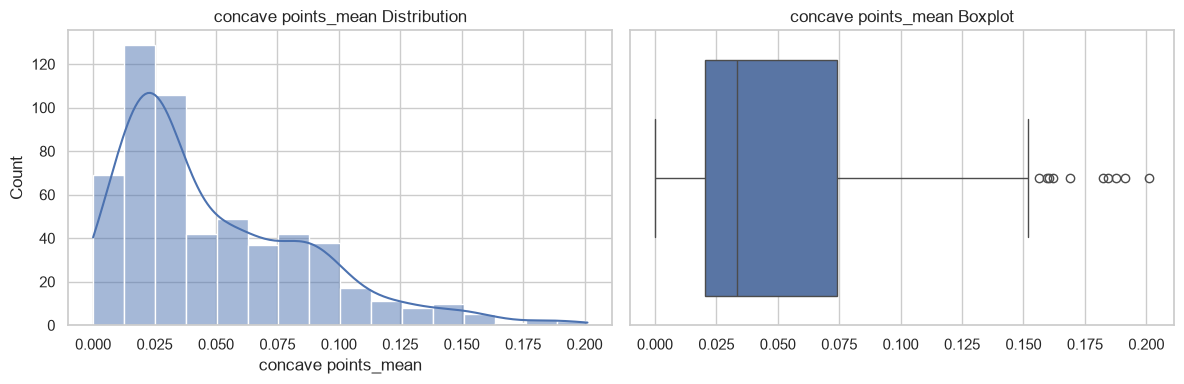

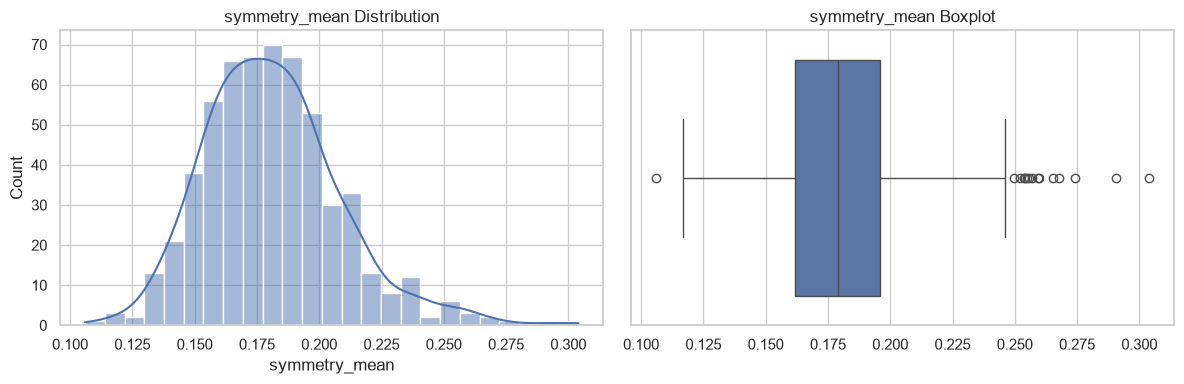

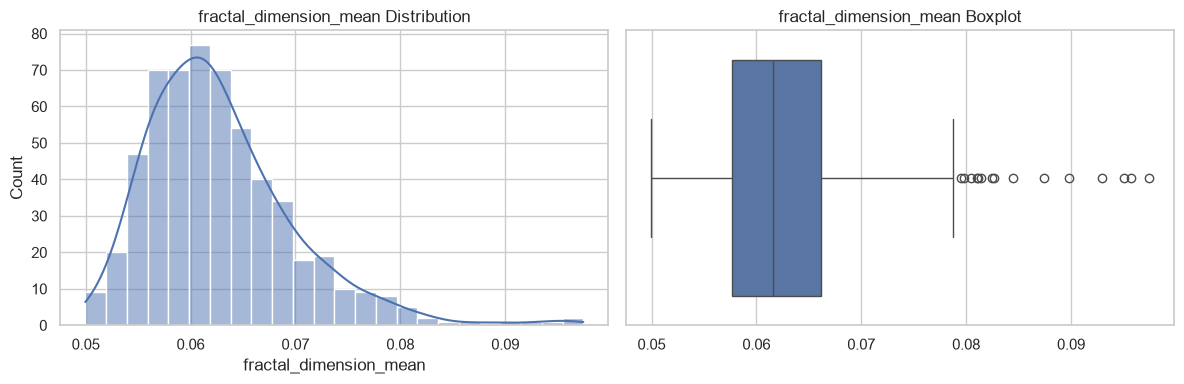

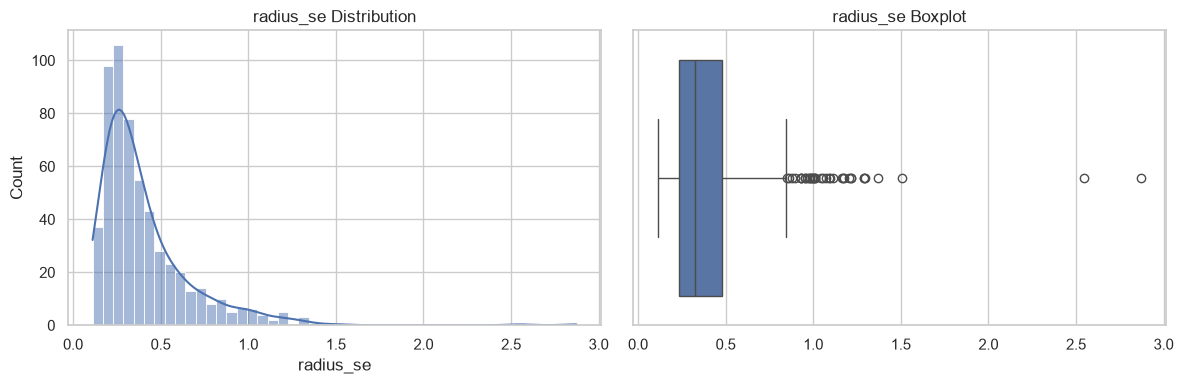

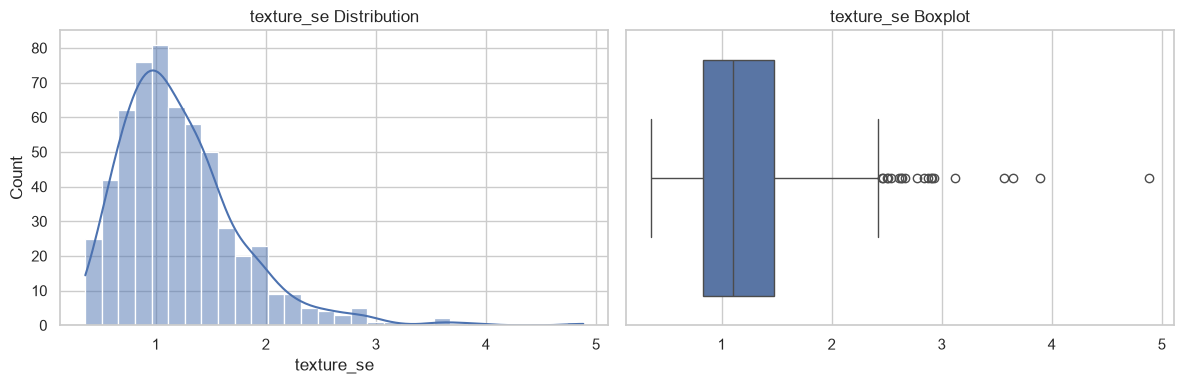

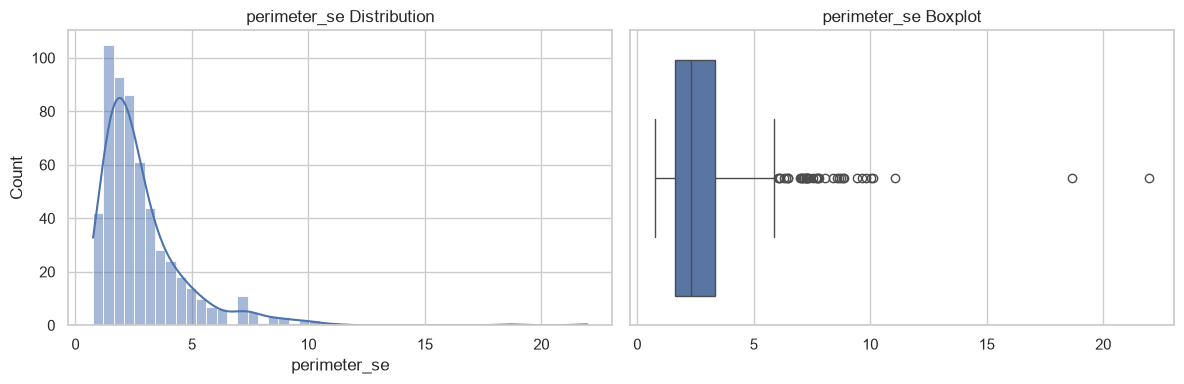

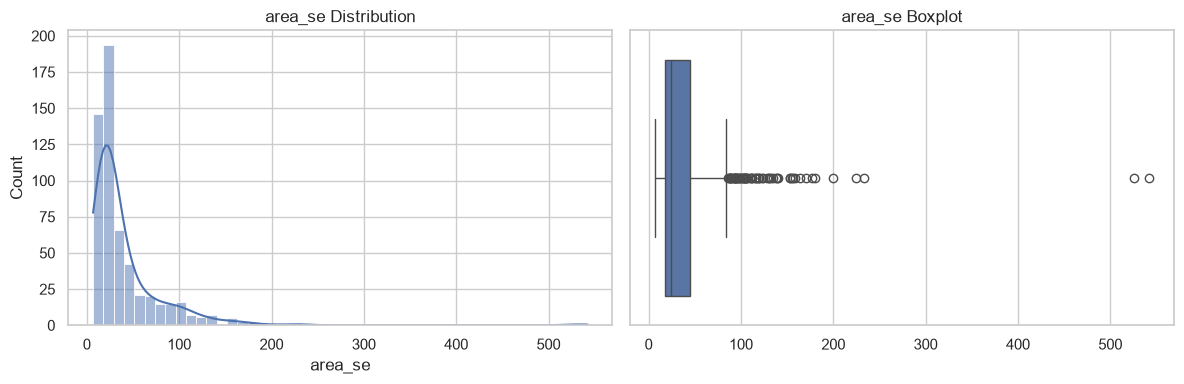

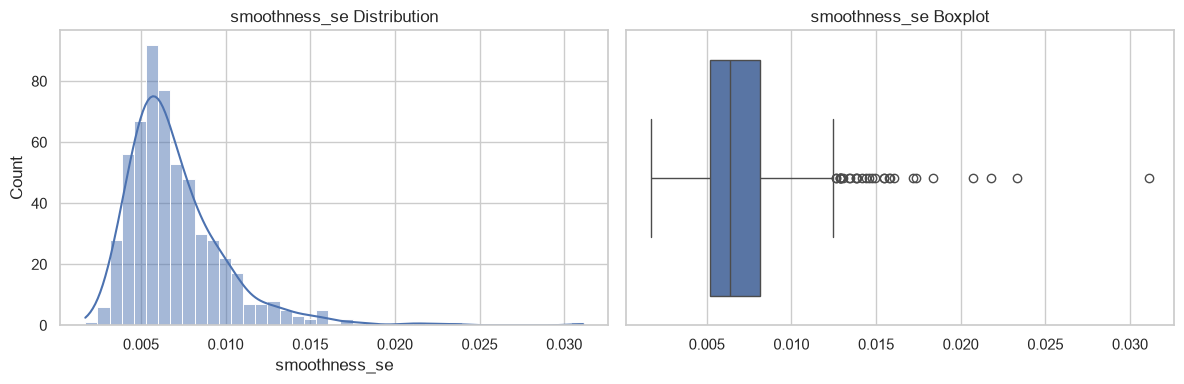

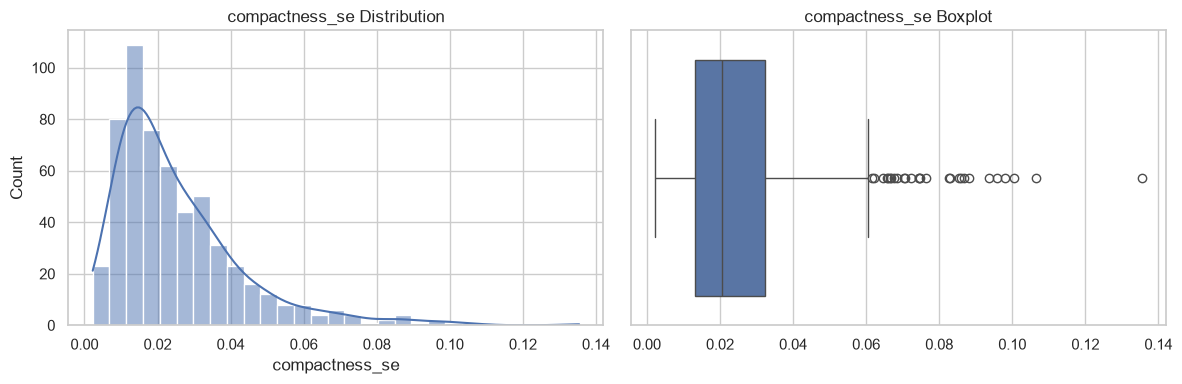

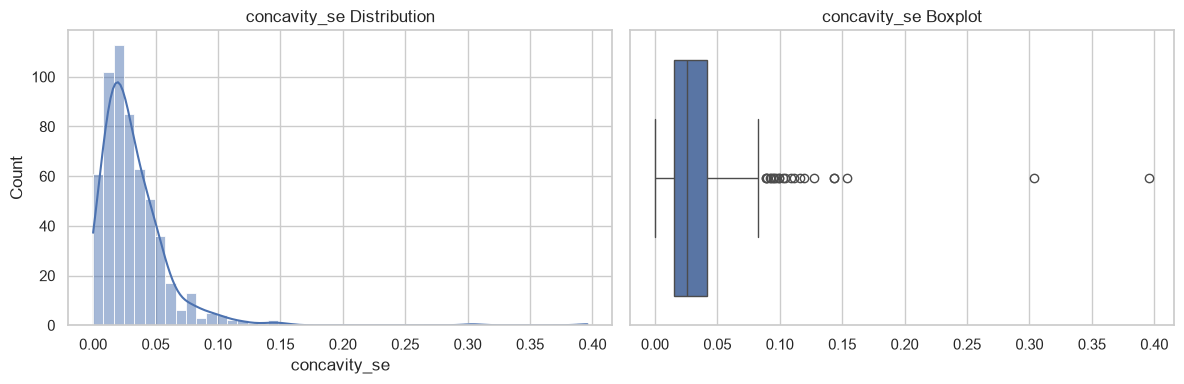

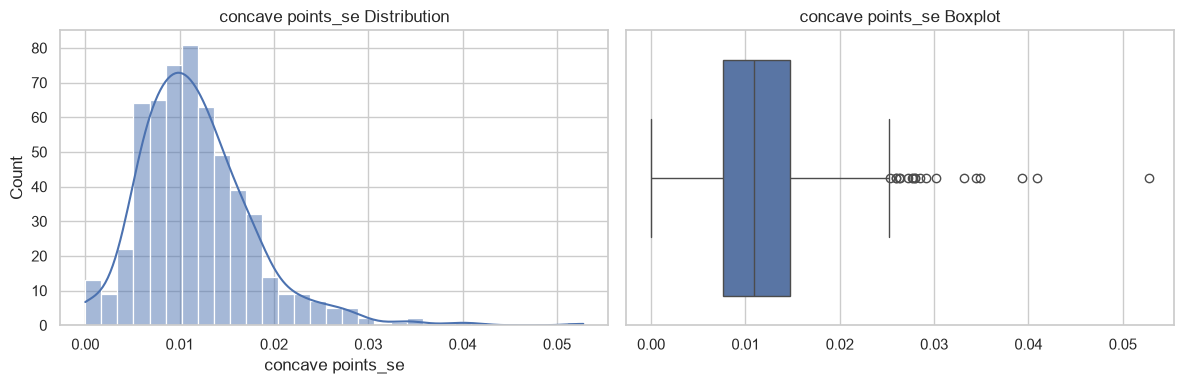

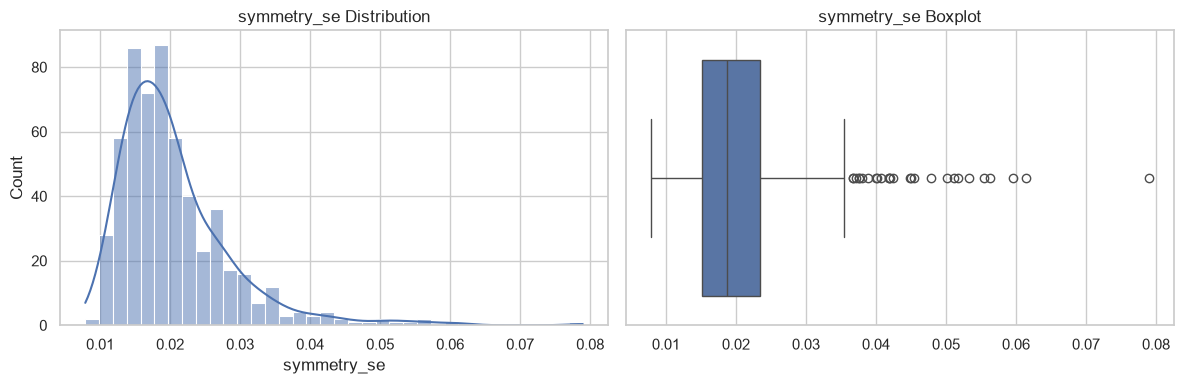

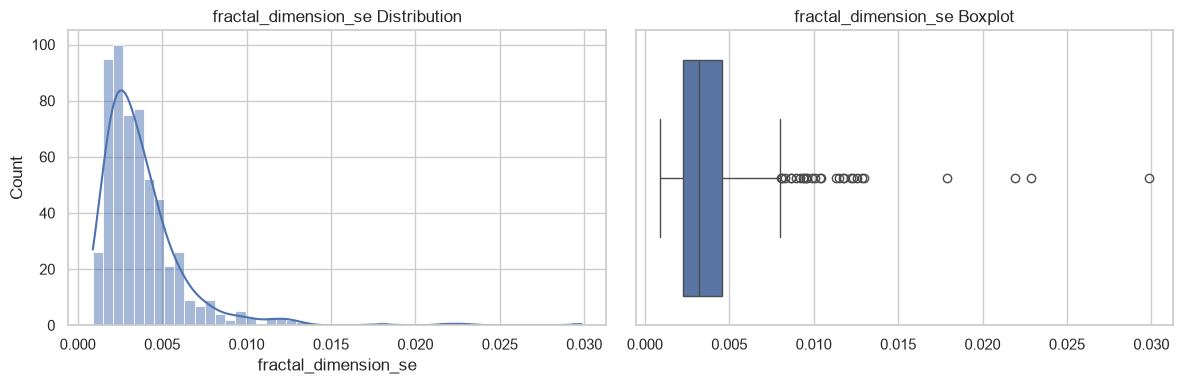

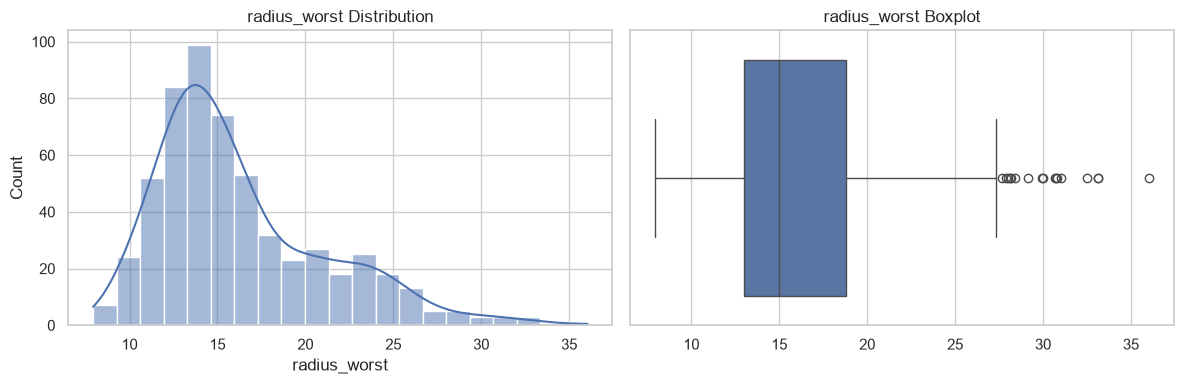

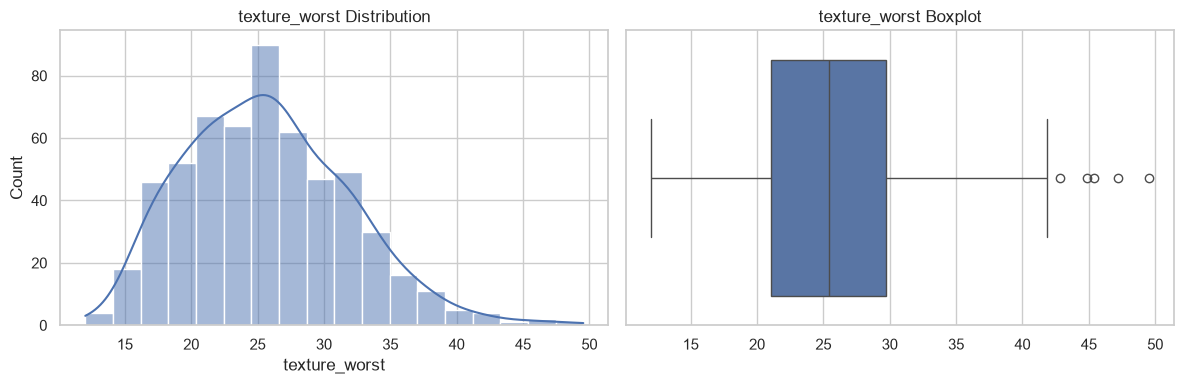

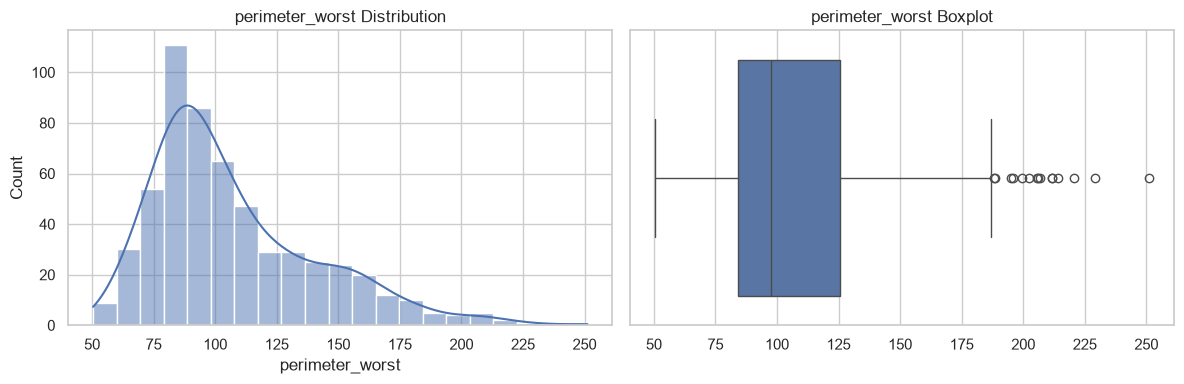

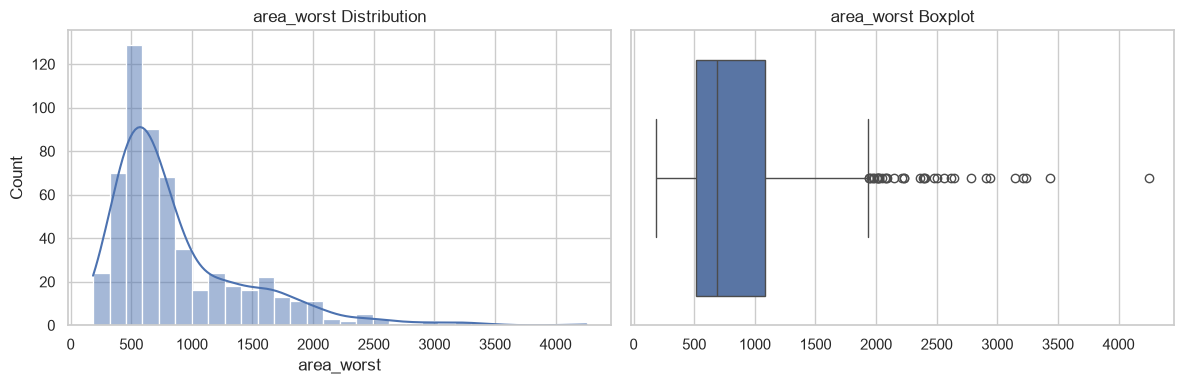

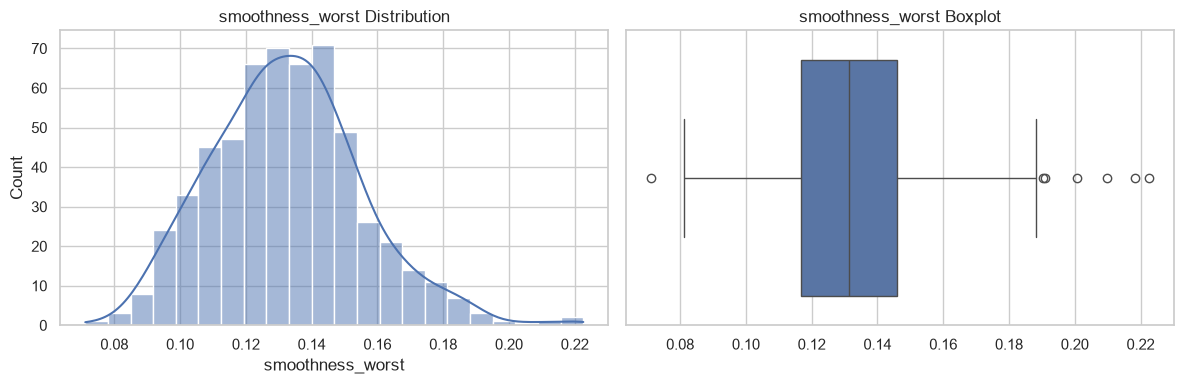

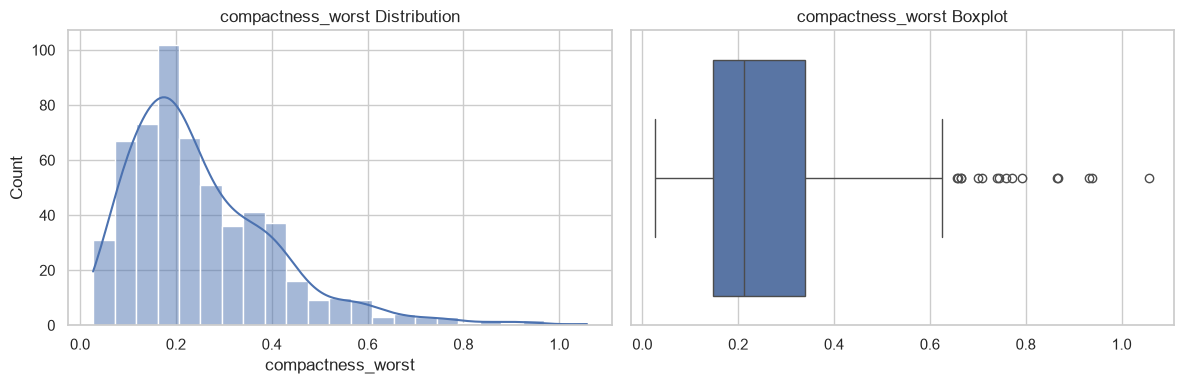

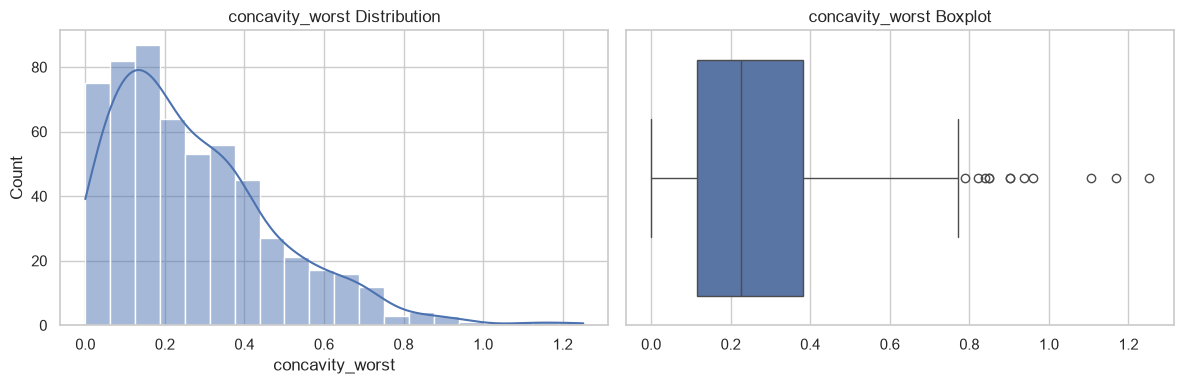

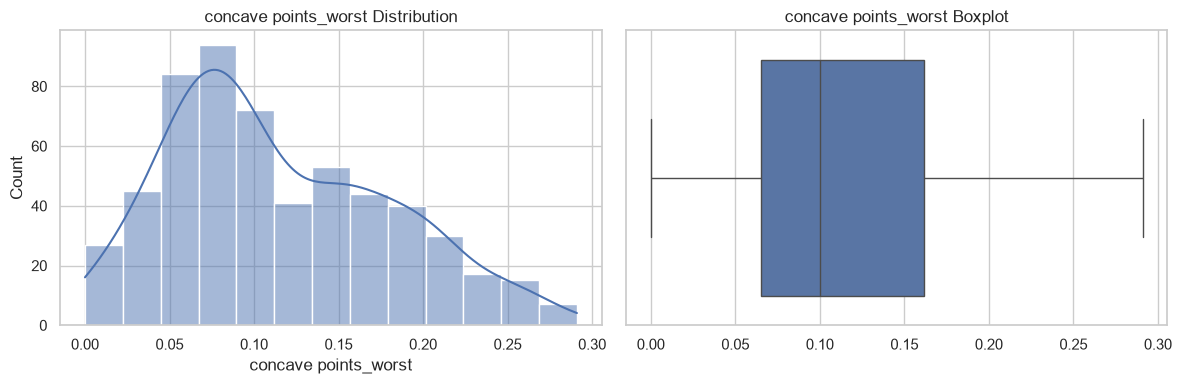

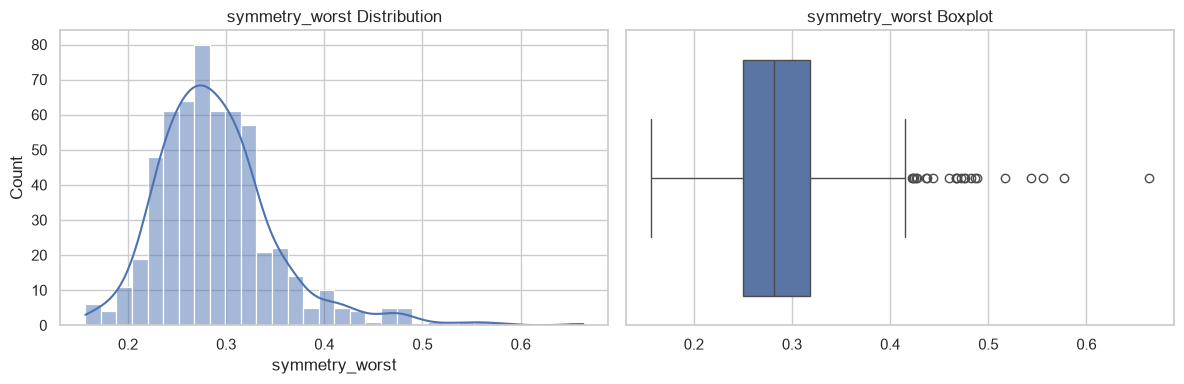

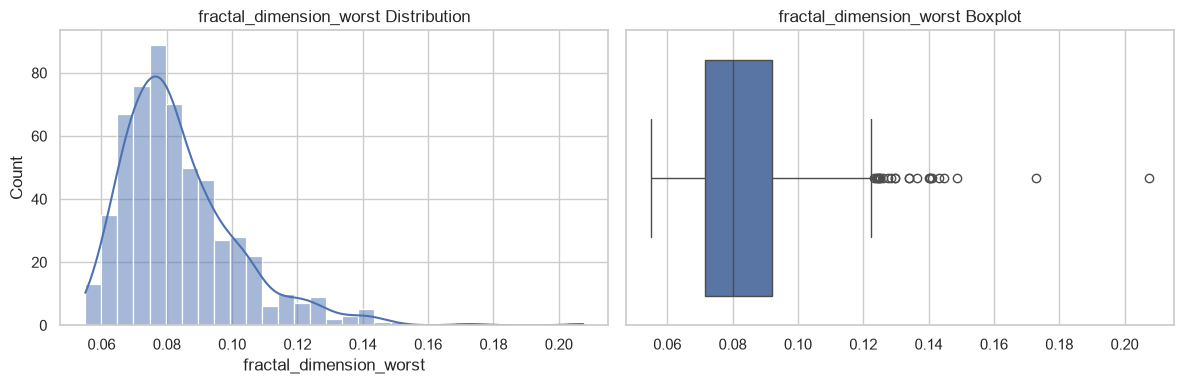

Preprocessing Completed
 Feature Engineering Completed

[PIPELINE COMPLETE]
Final Feature Shape: (569, 19)

Preprocessing completed.
Processed feature shape: (569, 19)
Target labels: [0, 1]

Selected features:
['smoothness_worst', 'compactness_mean', 'smoothness_se', 'texture_mean', 'concavity_mean', 'compactness_se', 'fractal_dimension_mean', 'fractal_dimension_se', 'fractal_dimension_worst', 'radius_mean', 'smoothness_mean', 'symmetry_se', 'symmetry_worst', 'radius_se', 'concavity_se', 'concave points_se', 'compactness_worst', 'interaction_feature', 'id']


In [48]:
# ============================================================
# Run the existing tabular preprocessing pipeline
# ============================================================

pipeline_result = tabular_pipeline(
    DATA_PATH,
    target_col=TARGET_COLUMN,
    task_type="classification",
    method="hybrid",
    k=20,
    variance_threshold=0.0,
    random_state=42
)

# Extract processed features and encode the target for classification metrics
X = pipeline_result["X"]
y = pipeline_result["y"].map({"B": 0, "M": 1})

if y.isna().any():
    raise ValueError("Target column contains values other than 'B' and 'M'.")

y = y.astype(int)

print("\nPreprocessing completed.")
print("Processed feature shape:", X.shape)
print("Target labels:", sorted(y.unique().tolist()))

print("\nSelected features:")
print(pipeline_result["selected_features"])

In [50]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples :", X_train.shape[0])
print("Testing samples  :", X_test.shape[0])

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

Training samples : 455
Testing samples  : 114

Training class distribution:
diagnosis
0    285
1    170
Name: count, dtype: int64

Testing class distribution:
diagnosis
0    72
1    42
Name: count, dtype: int64


In [51]:
# basic design of decision tree classifier

dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

print("Decision Tree trained successfully.")

Decision Tree trained successfully.


In [52]:
dt_accuracy = accuracy_score(y_test, dt_pred)

dt_precision = precision_score(
    y_test,
    dt_pred,
    zero_division=0
)

dt_recall = recall_score(
    y_test,
    dt_pred,
    zero_division=0
)

dt_f1 = f1_score(
    y_test,
    dt_pred,
    zero_division=0
)

print("Decision Tree Performance")
print("-------------------------")
print(f"Accuracy  : {dt_accuracy:.4f}")
print(f"Precision : {dt_precision:.4f}")
print(f"Recall    : {dt_recall:.4f}")
print(f"F1 Score  : {dt_f1:.4f}")

Decision Tree Performance
-------------------------
Accuracy  : 0.8947
Precision : 0.8750
Recall    : 0.8333
F1 Score  : 0.8537


Decision Tree Confusion Matrix:
[[67  5]
 [ 7 35]]


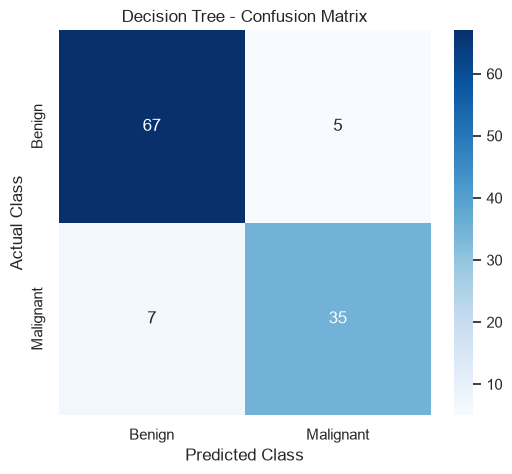

In [53]:
dt_cm = confusion_matrix(y_test, dt_pred)

print("Decision Tree Confusion Matrix:")
print(dt_cm)

plt.figure(figsize=(6, 5))

sns.heatmap(
    dt_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Benign", "Malignant"],
    yticklabels=["Benign", "Malignant"]
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Decision Tree - Confusion Matrix")

plt.show()

In [54]:
# Hyperparameter tuning for Decision Tree Classifier
dt_param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [2, 3, 4, 5, 6, 8, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

dt_grid = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=dt_param_grid,
    cv=cv,
    scoring={
        "accuracy": "accuracy",
        "f1": "f1"
    },
    refit="accuracy",
    n_jobs=-1
)

dt_grid.fit(X_train, y_train)

print("Decision Tree tuning completed.")

print("\nBest Parameters:")
print(dt_grid.best_params_)

print("\nBest Mean CV Accuracy:")
print(f"{dt_grid.cv_results_['mean_test_accuracy'][dt_grid.best_index_]:.4f}")

print("\nBest Mean CV F1 Score:")
print(f"{dt_grid.cv_results_['mean_test_f1'][dt_grid.best_index_]:.4f}")

Decision Tree tuning completed.

Best Parameters:
{'criterion': 'entropy', 'max_depth': 3, 'min_samples_leaf': 2, 'min_samples_split': 2}

Best Mean CV Accuracy:
0.9341

Best Mean CV F1 Score:
0.9086


In [ ]:
#hyperparameter tuning results table
dt_results = pd.DataFrame(dt_grid.cv_results_)

table1 = dt_results[
    [
        "param_criterion",
        "param_max_depth",
        "mean_test_accuracy",
        "mean_test_f1"
    ]
].copy()

table1.columns = [
    "Criterion",
    "Max Depth",
    "Avg CV Accuracy (%)",
    "Avg CV F1 Score"
]

table1["Avg CV Accuracy (%)"] *= 100

table1["Avg CV Accuracy (%)"] = table1["Avg CV Accuracy (%)"].round(2)
table1["Avg CV F1 Score"] = table1["Avg CV F1 Score"].round(4)

table1 = table1.sort_values(
    by="Avg CV Accuracy (%)",
    ascending=False
).reset_index(drop=True)

print("Table 1: Decision Tree Hyperparameter Evaluation using 5-Fold Cross-Validation")

display(table1)

Table 1: Decision Tree Hyperparameter Evaluation using 5-Fold Cross-Validation


,Criterion,Max Depth,Avg CV Accuracy (%),Avg CV F1 Score
0,entropy,3,93.41,0.9086
1,entropy,3,93.41,0.9086
2,entropy,3,93.41,0.9086
3,entropy,3,93.41,0.9086
4,entropy,3,93.19,0.9052
...,...,...,...,...
139,entropy,2,89.67,0.8597
140,entropy,2,89.67,0.8597
141,entropy,2,89.67,0.8597
142,entropy,2,89.67,0.8597


In [56]:
best_dt = dt_grid.best_estimator_

best_dt.fit(X_train, y_train)

best_dt_pred = best_dt.predict(X_test)

print("Best Decision Tree trained.")

Best Decision Tree trained.


In [57]:
#basic random forest classifier
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest trained successfully.")

Random Forest trained successfully.


In [58]:
#hyperparameter tuning for Random Forest Classifier
rf_param_grid = {
    "n_estimators": [50, 100, 150],
    "max_depth": [None, 5, 10, 15],
    "max_features": ["sqrt", "log2"],
    "bootstrap": [True, False]
}

rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=rf_param_grid,
    cv=cv,
    scoring={
        "accuracy": "accuracy",
        "f1": "f1"
    },
    refit="accuracy",
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

print("Random Forest tuning completed.")

print("\nBest Parameters:")
print(rf_grid.best_params_)

print("\nBest Mean CV Accuracy:")
print(
    f"{rf_grid.cv_results_['mean_test_accuracy'][rf_grid.best_index_]:.4f}"
)

print("\nBest Mean CV F1 Score:")
print(
    f"{rf_grid.cv_results_['mean_test_f1'][rf_grid.best_index_]:.4f}"
)

Random Forest tuning completed.

Best Parameters:
{'bootstrap': False, 'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 150}

Best Mean CV Accuracy:
0.9670

Best Mean CV F1 Score:
0.9552


In [59]:
rf_results = pd.DataFrame(rf_grid.cv_results_)

table2 = rf_results[
    [
        "param_n_estimators",
        "param_max_depth",
        "param_max_features",
        "mean_test_accuracy",
        "mean_test_f1"
    ]
].copy()

table2.columns = [
    "n estimators",
    "Max Depth",
    "Max Features",
    "Avg CV Accuracy (%)",
    "Avg CV F1 Score"
]

table2["Avg CV Accuracy (%)"] *= 100

table2["Avg CV Accuracy (%)"] = table2[
    "Avg CV Accuracy (%)"
].round(2)

table2["Avg CV F1 Score"] = table2[
    "Avg CV F1 Score"
].round(4)

table2 = table2.sort_values(
    by="Avg CV Accuracy (%)",
    ascending=False
).reset_index(drop=True)

print("Table 2: Random Forest Hyperparameter Evaluation using 5-Fold Cross-Validation")

display(table2)

Table 2: Random Forest Hyperparameter Evaluation using 5-Fold Cross-Validation


,n estimators,Max Depth,Max Features,Avg CV Accuracy (%),Avg CV F1 Score
0,150,10,sqrt,96.70,0.9552
1,150,15,log2,96.70,0.9552
2,150,15,sqrt,96.70,0.9552
3,150,10,log2,96.70,0.9552
4,150,None,sqrt,96.70,0.9552
5,150,None,log2,96.70,0.9552
6,100,None,log2,96.48,0.9520
7,100,None,sqrt,96.48,0.9520
8,100,10,log2,96.48,0.9520
9,100,10,sqrt,96.48,0.9520


In [60]:
best_rf = rf_grid.best_estimator_

best_rf.fit(X_train, y_train)

best_rf_pred = best_rf.predict(X_test)

print("Best Random Forest trained.")

Best Random Forest trained.


In [61]:
dt_final_pred = best_dt.predict(X_test)

dt_final_accuracy = accuracy_score(
    y_test,
    dt_final_pred
)

dt_final_precision = precision_score(
    y_test,
    dt_final_pred,
    zero_division=0
)

dt_final_recall = recall_score(
    y_test,
    dt_final_pred,
    zero_division=0
)

dt_final_f1 = f1_score(
    y_test,
    dt_final_pred,
    zero_division=0
)

print("Decision Tree - Final Test Performance")
print("---------------------------------------")
print(f"Accuracy  : {dt_final_accuracy:.4f}")
print(f"Precision : {dt_final_precision:.4f}")
print(f"Recall    : {dt_final_recall:.4f}")
print(f"F1-score  : {dt_final_f1:.4f}")

Decision Tree - Final Test Performance
---------------------------------------
Accuracy  : 0.9211
Precision : 0.9231
Recall    : 0.8571
F1-score  : 0.8889


In [62]:
rf_final_pred = best_rf.predict(X_test)

rf_final_accuracy = accuracy_score(
    y_test,
    rf_final_pred
)

rf_final_precision = precision_score(
    y_test,
    rf_final_pred,
    zero_division=0
)

rf_final_recall = recall_score(
    y_test,
    rf_final_pred,
    zero_division=0
)

rf_final_f1 = f1_score(
    y_test,
    rf_final_pred,
    zero_division=0
)

print("Random Forest - Final Test Performance")
print("---------------------------------------")
print(f"Accuracy  : {rf_final_accuracy:.4f}")
print(f"Precision : {rf_final_precision:.4f}")
print(f"Recall    : {rf_final_recall:.4f}")
print(f"F1-score  : {rf_final_f1:.4f}")

Random Forest - Final Test Performance
---------------------------------------
Accuracy  : 0.9386
Precision : 0.9487
Recall    : 0.8810
F1-score  : 0.9136


In [63]:
final_comparison = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Random Forest"
    ],

    "Accuracy": [
        dt_final_accuracy,
        rf_final_accuracy
    ],

    "Precision": [
        dt_final_precision,
        rf_final_precision
    ],

    "Recall": [
        dt_final_recall,
        rf_final_recall
    ],

    "F1-score": [
        dt_final_f1,
        rf_final_f1
    ]
})

display(final_comparison.round(4))

,Model,Accuracy,Precision,Recall,F1-score
0,Decision Tree,0.9211,0.9231,0.8571,0.8889
1,Random Forest,0.9386,0.9487,0.8810,0.9136


Decision Tree AUC : 0.9439
Random Forest AUC : 0.9902


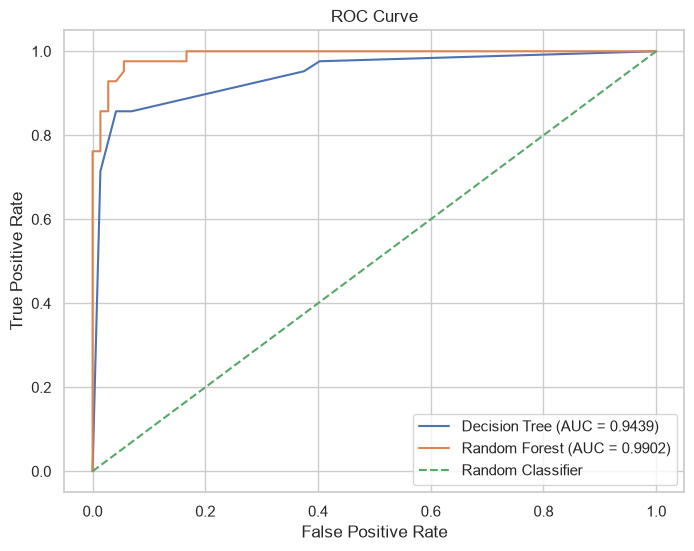

In [64]:
# Probability of malignant class
dt_prob = best_dt.predict_proba(X_test)[:, 1]
rf_prob = best_rf.predict_proba(X_test)[:, 1]

# ROC values
dt_fpr, dt_tpr, _ = roc_curve(y_test, dt_prob)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)

# AUC
dt_auc = roc_auc_score(y_test, dt_prob)
rf_auc = roc_auc_score(y_test, rf_prob)

print(f"Decision Tree AUC : {dt_auc:.4f}")
print(f"Random Forest AUC : {rf_auc:.4f}")

# Plot
plt.figure(figsize=(8, 6))

plt.plot(
    dt_fpr,
    dt_tpr,
    label=f"Decision Tree (AUC = {dt_auc:.4f})"
)

plt.plot(
    rf_fpr,
    rf_tpr,
    label=f"Random Forest (AUC = {rf_auc:.4f})"
)

# Random classifier baseline
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()